In [1]:
# CELL 1 — IMPORTS AND CONFIGURATION
import json, math, random, shutil, zipfile
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, brier_score_loss, confusion_matrix,
    f1_score, precision_recall_fscore_support, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import FileLink, display

SEED=42
random.seed(SEED);np.random.seed(SEED)
OUTPUT_DIR=Path("/kaggle/working/defakex_experiment_3")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
ANNOTATION_CSV=Path("/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_annotations_final.csv")

CV_SEEDS=[42,123,2026]
CANDIDATE_C=[0.003,0.01,0.03]
N_SPLITS=3
BOOTSTRAP_ITERATIONS=1000

print("OUTPUT_DIR:",OUTPUT_DIR)
print("This experiment uses cached frozen features and can run on CPU.")

OUTPUT_DIR: /kaggle/working/defakex_experiment_3
This experiment uses cached frozen features and can run on CPU.


In [4]:
# CELL 2 — LOCATE OR EXTRACT EXPERIMENT 2 FEATURE CACHE
def find_unique(filename,roots):
    matches=[]
    for root in roots:
        if root.exists():matches.extend(root.rglob(filename))
    # Prefer working output, then shortest input path.
    matches=sorted(set(matches),key=lambda p:(0 if "/kaggle/working/defakex_experiment_2/" in str(p) else 1,len(p.parts)))
    return matches[0] if matches else None

roots=[Path("/kaggle/working"),Path("/kaggle/input")]
FEATURE_CACHE=find_unique("Experiment2_Frozen_Features.npz",roots)
META_CACHE=find_unique("Experiment2_Frozen_Feature_Metadata.csv",roots)

if FEATURE_CACHE is None or META_CACHE is None:
    zip_matches=[]
    for root in roots:
        if root.exists():zip_matches.extend(root.rglob("*Experiment2*.zip"))
    if zip_matches:
        target=Path("/kaggle/working/experiment2_import");target.mkdir(parents=True,exist_ok=True)
        with zipfile.ZipFile(zip_matches[0]) as z:z.extractall(target)
        FEATURE_CACHE=find_unique("Experiment2_Frozen_Features.npz",[target])
        META_CACHE=find_unique("Experiment2_Frozen_Feature_Metadata.csv",[target])

assert FEATURE_CACHE is not None and META_CACHE is not None,(
    "Experiment 2 feature cache was not found. In the same Kaggle session, keep "
    "/kaggle/working/defakex_experiment_2. Otherwise upload/add the Experiment 2 results ZIP as a Kaggle input dataset."
)

print("FEATURE_CACHE:",FEATURE_CACHE)
print("META_CACHE:",META_CACHE)

FEATURE_CACHE: /kaggle/input/datasets/kashirhanif/experiment-result/Experiment2_Frozen_Features.npz
META_CACHE: /kaggle/input/datasets/kashirhanif/experiment-result/Experiment2_Frozen_Feature_Metadata.csv


In [5]:
# CELL 3 — LOAD, ALIGN, AND VERIFY FEATURES
feature_meta=pd.read_csv(META_CACHE,dtype={"image_id":str})
cached=np.load(FEATURE_CACHE)
frequency_embeddings=np.asarray(cached["frequency_embeddings"],dtype=np.float32)
spatial_embeddings=np.asarray(cached["spatial_embeddings"],dtype=np.float32)

assert len(feature_meta)==5093
assert frequency_embeddings.shape==(5093,1536)
assert spatial_embeddings.shape==(5093,1536)
assert np.isfinite(frequency_embeddings).all() and np.isfinite(spatial_embeddings).all()
assert feature_meta["image_id"].is_unique
assert feature_meta["split"].value_counts().to_dict()=={"train":4194,"validation":899}
assert set(feature_meta["split"])=={"train","validation"}

# Enrich with annotation slices without changing feature order.
if ANNOTATION_CSV.exists():
    ann=pd.read_csv(ANNOTATION_CSV,dtype=str,keep_default_na=False)
    ann.columns=[c.strip().lower() for c in ann.columns]
    keep=[c for c in ["image_id","framing","lighting","face_count","source","generator","actual_format","file_format","identity_group","provenance_group","actual_sha256","sha256"] if c in ann.columns]
    enrichment=ann[keep].drop_duplicates("image_id")
    feature_meta=feature_meta.merge(enrichment,on="image_id",how="left",suffixes=("","_annotation"),validate="one_to_one")

print(feature_meta["split"].value_counts())
print(pd.crosstab([feature_meta["split"],feature_meta["source"]],feature_meta["label_norm"],margins=True))
print("PASS: 5,093 aligned development feature rows; locked benchmark absent.")

split
train         4194
validation     899
Name: count, dtype: int64
label_norm          fake  real   All
split      source                   
train      chatgpt  1050     0  1050
           gemini   1051     0  1051
           real        0  2093  2093
validation chatgpt   225     0   225
           gemini    225     0   225
           real        0   449   449
All                 2551  2542  5093
PASS: 5,093 aligned development feature rows; locked benchmark absent.


In [6]:
# CELL 4 — BUILD STRICTER GROUPS AND FEATURE ABLATIONS
def strict_group(row):
    # Preserve explicit real/AI-edit provenance first.
    for col in ("provenance_group","provenance_group_annotation"):
        value=str(row.get(col,"")).strip()
        if value and value.lower()!="nan":return "provenance:"+value

    # All real images under the same person/source folder stay together in CV.
    if str(row["label_norm"]).lower()=="real":
        parts=str(row["filepath"]).replace("\\","/").split("/")
        lowered=[p.lower() for p in parts]
        if "real" in lowered:
            i=lowered.index("real")
            if i+1<len(parts):return "real_identity:"+parts[i+1].lower()

    # Retain the group generated in Experiment 2 if available.
    value=str(row.get("cv_group","")).strip()
    if value and value.lower()!="nan":return value
    return "image:"+str(row["image_id"])

feature_meta["strict_group"]=feature_meta.apply(strict_group,axis=1)
meta_features=feature_meta[["face_found","face_confidence","face_count","face_area_ratio"]].to_numpy(dtype=np.float32)
expert_logits=feature_meta[["frequency_logit","spatial_logit","auxiliary_logit"]].to_numpy(dtype=np.float32)

feature_sets={
    "metadata_only":meta_features,
    "old_logits_plus_metadata":np.concatenate([expert_logits,meta_features],axis=1),
    "frequency_embedding":frequency_embeddings,
    "spatial_embedding_plus_metadata":np.concatenate([spatial_embeddings,meta_features],axis=1),
    "frequency_plus_spatial_embeddings":np.concatenate([frequency_embeddings,spatial_embeddings],axis=1),
    "embeddings_plus_metadata":np.concatenate([frequency_embeddings,spatial_embeddings,meta_features],axis=1),
    "embeddings_plus_old_logits":np.concatenate([frequency_embeddings,spatial_embeddings,expert_logits],axis=1),
    "embeddings_logits_metadata":np.concatenate([frequency_embeddings,spatial_embeddings,expert_logits,meta_features],axis=1),
}

train_mask=feature_meta["split"].eq("train").to_numpy();val_mask=feature_meta["split"].eq("validation").to_numpy()
y_train=feature_meta.loc[train_mask,"true_label"].astype(int).to_numpy();y_val=feature_meta.loc[val_mask,"true_label"].astype(int).to_numpy()
groups_train=feature_meta.loc[train_mask,"strict_group"].astype(str).to_numpy()

print("Strict training CV groups:",len(np.unique(groups_train)),"from",len(groups_train),"images")
print({k:v.shape[1] for k,v in feature_sets.items()})
assert train_mask.sum()==4194 and val_mask.sum()==899
print("PASS: locked-test features are not present.")

Strict training CV groups: 2080 from 4194 images
{'metadata_only': 4, 'old_logits_plus_metadata': 7, 'frequency_embedding': 1536, 'spatial_embedding_plus_metadata': 1540, 'frequency_plus_spatial_embeddings': 3072, 'embeddings_plus_metadata': 3076, 'embeddings_plus_old_logits': 3075, 'embeddings_logits_metadata': 3079}
PASS: locked-test features are not present.


In [8]:
# CELL 5 — HELPERS FOR GROUPED MODEL SELECTION AND METRICS
def make_model(C):
    return Pipeline([
        ("scale",StandardScaler()),
        ("classifier",LogisticRegression(C=C,class_weight="balanced",solver="liblinear",max_iter=2500,random_state=SEED)),
    ])

def select_threshold(y,p):
    candidates=[]
    for t in np.linspace(0.05,0.95,181):
        pred=(p>=t).astype(int)
        candidates.append((float(t),f1_score(y,pred,average="macro",zero_division=0),balanced_accuracy_score(y,pred)))
    return max(candidates,key=lambda x:(x[1],x[2]))

def metric_row(y,p,t,name):
    y=np.asarray(y,dtype=int);p=np.asarray(p,dtype=float);pred=(p>=t).astype(int)
    precision,recall,f1,support=precision_recall_fscore_support(y,pred,labels=[0,1],zero_division=0)
    cm=confusion_matrix(y,pred,labels=[0,1])
    return {"model":name,"threshold":float(t),"n":len(y),"accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),"macro_f1":f1_score(y,pred,average="macro",zero_division=0),
        "roc_auc":roc_auc_score(y,p),"brier_score":brier_score_loss(y,p),
        "real_recall":recall[0],"fake_recall":recall[1],"real_f1":f1[0],"fake_f1":f1[1],
        "tn":int(cm[0,0]),"fp":int(cm[0,1]),"fn":int(cm[1,0]),"tp":int(cm[1,1])}

def expected_calibration_error(y,p,bins=10):
    edges=np.linspace(0,1,bins+1);ece=0.
    for lo,hi in zip(edges[:-1],edges[1:]):
        mask=(p>=lo)&(p<(hi if hi<1 else hi+1e-9))
        if mask.any():ece+=mask.mean()*abs(y[mask].mean()-p[mask].mean())
    return float(ece)

print("Helpers ready.")

Helpers ready.


In [9]:
# CELL 6 — CANONICAL GROUPED CV: SELECT C AND TRAIN-ONLY THRESHOLD
# The canonical seed selects C and threshold. Validation is not used for either.
canonical_seed=CV_SEEDS[0]
cv=StratifiedGroupKFold(n_splits=N_SPLITS,shuffle=True,random_state=canonical_seed)
selection_rows=[];selected={}

for name,matrix in feature_sets.items():
    X=matrix[train_mask]
    best_C=None;best_auc=-np.inf
    for C in CANDIDATE_C:
        oof=np.full(len(y_train),np.nan)
        for fit_idx,hold_idx in cv.split(X,y_train,groups_train):
            model=make_model(C);model.fit(X[fit_idx],y_train[fit_idx]);oof[hold_idx]=model.predict_proba(X[hold_idx])[:,1]
        auc=roc_auc_score(y_train,oof)
        selection_rows.append({"feature_set":name,"C":C,"seed":canonical_seed,"oof_auc":auc})
        if auc>best_auc:best_auc=auc;best_C=C;best_oof=oof.copy()
    threshold,oof_f1,oof_bal=select_threshold(y_train,best_oof)
    selected[name]={"C":best_C,"threshold":threshold,"canonical_oof_auc":best_auc,"canonical_oof_macro_f1":oof_f1,"canonical_oof_balanced_accuracy":oof_bal}

selection_df=pd.DataFrame(selection_rows)
selection_df.to_csv(OUTPUT_DIR/"Experiment3_C_Selection.csv",index=False)
display(pd.DataFrame(selected).T.sort_values("canonical_oof_auc",ascending=False))
print("PASS: C and thresholds selected from grouped training OOF predictions only.")

,C,threshold,canonical_oof_auc,canonical_oof_macro_f1,canonical_oof_balanced_accuracy
frequency_plus_spatial_embeddings,0.010,0.665,0.965233,0.905088,0.905129
embeddings_plus_old_logits,0.010,0.665,0.965232,0.905088,0.905129
embeddings_plus_metadata,0.010,0.630,0.964333,0.904625,0.904633
embeddings_logits_metadata,0.010,0.685,0.964328,0.904587,0.904667
frequency_embedding,0.010,0.605,0.938230,0.870278,0.870313
spatial_embedding_plus_metadata,0.010,0.520,0.903657,0.820984,0.821321
old_logits_plus_metadata,0.003,0.485,0.626098,0.597281,0.604183
metadata_only,0.003,0.500,0.445865,0.477020,0.477087


PASS: C and thresholds selected from grouped training OOF predictions only.


In [10]:
# CELL 7 — REPEATED GROUP-CV STABILITY WITH FIXED SELECTED C
stability_rows=[]
for name,matrix in feature_sets.items():
    X=matrix[train_mask];C=selected[name]["C"]
    for seed in CV_SEEDS:
        cv_seed=StratifiedGroupKFold(n_splits=N_SPLITS,shuffle=True,random_state=seed)
        oof=np.full(len(y_train),np.nan)
        for fit_idx,hold_idx in cv_seed.split(X,y_train,groups_train):
            model=make_model(C);model.fit(X[fit_idx],y_train[fit_idx]);oof[hold_idx]=model.predict_proba(X[hold_idx])[:,1]
        t,mf1,bal=select_threshold(y_train,oof)
        stability_rows.append({"feature_set":name,"seed":seed,"C":C,"oof_auc":roc_auc_score(y_train,oof),"oof_macro_f1":mf1,"oof_balanced_accuracy":bal,"oof_threshold":t})

stability_df=pd.DataFrame(stability_rows)
stability_summary=stability_df.groupby("feature_set").agg(
    mean_oof_auc=("oof_auc","mean"),std_oof_auc=("oof_auc","std"),
    mean_oof_macro_f1=("oof_macro_f1","mean"),std_oof_macro_f1=("oof_macro_f1","std"),
    min_oof_auc=("oof_auc","min"),max_oof_auc=("oof_auc","max"),
).reset_index().sort_values("mean_oof_auc",ascending=False)
stability_df.to_csv(OUTPUT_DIR/"Experiment3_Repeated_GroupCV.csv",index=False)
stability_summary.to_csv(OUTPUT_DIR/"Experiment3_Stability_Summary.csv",index=False)
display(stability_summary)
print("Lower standard deviation means the feature set is less dependent on one lucky fold split.")

,feature_set,mean_oof_auc,std_oof_auc,mean_oof_macro_f1,std_oof_macro_f1,min_oof_auc,max_oof_auc
4,frequency_plus_spatial_embeddings,0.962698,0.002859,0.900485,0.004162,0.959599,0.965233
2,embeddings_plus_old_logits,0.962688,0.002859,0.900485,0.004162,0.959594,0.965232
1,embeddings_plus_metadata,0.961901,0.002760,0.900088,0.004019,0.958902,0.964333
0,embeddings_logits_metadata,0.961890,0.002759,0.900075,0.003998,0.958895,0.964328
3,frequency_embedding,0.936374,0.002766,0.868137,0.002418,0.933195,0.938230
7,spatial_embedding_plus_metadata,0.902396,0.001673,0.819384,0.002434,0.900498,0.903657
6,old_logits_plus_metadata,0.625193,0.001190,0.596133,0.001299,0.623845,0.626098
5,metadata_only,0.437875,0.006949,0.471813,0.004511,0.433244,0.445865


Lower standard deviation means the feature set is less dependent on one lucky fold split.


In [11]:
# CELL 8 — FIT FINAL ABLATIONS AND EVALUATE THE FIXED VALIDATION SPLIT
validation_rows=[];validation_predictions=[];trained_models={}
for name,matrix in feature_sets.items():
    X_train=matrix[train_mask];X_val=matrix[val_mask]
    model=make_model(selected[name]["C"]);model.fit(X_train,y_train)
    p=model.predict_proba(X_val)[:,1];t=selected[name]["threshold"]
    row=metric_row(y_val,p,t,name);row.update(selected[name]);row["ece_10_bins"]=expected_calibration_error(y_val,p)
    validation_rows.append(row);trained_models[name]=model
    joblib.dump(model,OUTPUT_DIR/f"Experiment3_{name}.joblib")
    temp=feature_meta.loc[val_mask,["image_id","filepath","label_norm","true_label","source","face_found","face_count","face_area_ratio"]].copy()
    temp["model"]=name;temp["fake_probability"]=p;temp["threshold"]=t;temp["prediction"]=(p>=t).astype(int);temp["correct"]=(temp["prediction"]==temp["true_label"]).astype(int)
    validation_predictions.append(temp)

validation_metrics=pd.DataFrame(validation_rows).sort_values(["roc_auc","macro_f1"],ascending=False)
validation_predictions=pd.concat(validation_predictions,ignore_index=True)
validation_metrics.to_csv(OUTPUT_DIR/"Experiment3_Validation_Ablation_Metrics.csv",index=False)
validation_predictions.to_csv(OUTPUT_DIR/"Experiment3_Validation_Predictions.csv",index=False)
display(validation_metrics)

best_name=validation_metrics.iloc[0]["model"]
best_model=trained_models[best_name]
joblib.dump(best_model,OUTPUT_DIR/"Experiment3_Best_Frozen_Embedding_Fusion.joblib")
print("Best validation-AUC ablation:",best_name)
print("This is a development selection using validation; the locked benchmark remains untouched.")

,model,threshold,n,accuracy,balanced_accuracy,macro_f1,roc_auc,brier_score,real_recall,fake_recall,...,fake_f1,tn,fp,fn,tp,C,canonical_oof_auc,canonical_oof_macro_f1,canonical_oof_balanced_accuracy,ece_10_bins
5,embeddings_plus_metadata,0.630,899,0.924360,0.924390,0.924311,0.981089,0.054374,0.951002,0.897778,...,0.922374,427,22,46,404,0.010,0.964333,0.904625,0.904633,0.024413
7,embeddings_logits_metadata,0.685,899,0.923248,0.923294,0.923125,0.981089,0.054379,0.964365,0.882222,...,0.920046,433,16,53,397,0.010,0.964328,0.904587,0.904667,0.024411
4,frequency_plus_spatial_embeddings,0.665,899,0.927697,0.927736,0.927617,0.981059,0.054518,0.962138,0.893333,...,0.925201,432,17,48,402,0.010,0.965233,0.905088,0.905129,0.022854
6,embeddings_plus_old_logits,0.665,899,0.927697,0.927736,0.927617,0.981054,0.054511,0.962138,0.893333,...,0.925201,432,17,48,402,0.010,0.965232,0.905088,0.905129,0.022855
2,frequency_embedding,0.605,899,0.870968,0.870992,0.870910,0.948171,0.091665,0.893096,0.848889,...,0.868182,401,48,68,382,0.010,0.938230,0.870278,0.870313,0.031230
3,spatial_embedding_plus_metadata,0.520,899,0.838710,0.838654,0.838286,0.931720,0.106123,0.788419,0.888889,...,0.846561,354,95,50,400,0.010,0.903657,0.820984,0.821321,0.032456
1,old_logits_plus_metadata,0.485,899,0.609566,0.609431,0.603632,0.631675,0.233696,0.487751,0.731111,...,0.652131,219,230,121,329,0.003,0.626098,0.597281,0.604183,0.059030
0,metadata_only,0.500,899,0.599555,0.599505,0.598720,0.580277,0.250303,0.554566,0.644444,...,0.617021,249,200,160,290,0.003,0.445865,0.477020,0.477087,0.093970


Best validation-AUC ablation: embeddings_plus_metadata
This is a development selection using validation; the locked benchmark remains untouched.


In [12]:
# CELL 9 — SOURCE AND FACE-AVAILABILITY SLICES
slice_rows=[]
for model_name,gmodel in validation_predictions.groupby("model"):
    for source,g in gmodel.groupby("source"):
        expected=0 if source=="real" else 1
        slice_rows.append({"model":model_name,"slice_type":"source","slice":source,"n":len(g),
            "class_recall":float((g["prediction"].astype(int)==expected).mean()),
            "accuracy":float(g["correct"].mean()),"mean_fake_probability":float(g["fake_probability"].mean())})
    for found,g in gmodel.groupby("face_found"):
        slice_rows.append({"model":model_name,"slice_type":"face_found","slice":str(bool(found)),"n":len(g),
            "class_recall":np.nan,"accuracy":float(g["correct"].mean()),"mean_fake_probability":float(g["fake_probability"].mean())})

slice_metrics=pd.DataFrame(slice_rows)
slice_metrics.to_csv(OUTPUT_DIR/"Experiment3_Validation_Slice_Metrics.csv",index=False)
display(slice_metrics[(slice_metrics["model"].eq(best_name)) & (slice_metrics["slice_type"].eq("source"))])
display(slice_metrics[(slice_metrics["model"].eq(best_name)) & (slice_metrics["slice_type"].eq("face_found"))])

,model,slice_type,slice,n,class_recall,accuracy,mean_fake_probability
5,embeddings_plus_metadata,source,chatgpt,225,0.835556,0.835556,0.834971
6,embeddings_plus_metadata,source,gemini,225,0.960000,0.960000,0.945712
7,embeddings_plus_metadata,source,real,449,0.951002,0.951002,0.125927


,model,slice_type,slice,n,class_recall,accuracy,mean_fake_probability
8,embeddings_plus_metadata,face_found,False,55,NaN,0.781818,0.420192
9,embeddings_plus_metadata,face_found,True,844,NaN,0.933649,0.514318


In [13]:
# CELL 10 — LEAVE-ONE-GENERATOR-OUT GENERALIZATION
# Train on real + one fake generator; evaluate on validation real + the unseen fake generator.
best_matrix=feature_sets[best_name]
logo_rows=[];logo_predictions=[]

for seen_generator,unseen_generator in [("gemini","chatgpt"),("chatgpt","gemini")]:
    fit_mask=train_mask & feature_meta["source"].isin(["real",seen_generator]).to_numpy()
    eval_mask=val_mask & feature_meta["source"].isin(["real",unseen_generator]).to_numpy()
    X_fit=best_matrix[fit_mask];y_fit=feature_meta.loc[fit_mask,"true_label"].astype(int).to_numpy();g_fit=feature_meta.loc[fit_mask,"strict_group"].astype(str).to_numpy()
    X_eval=best_matrix[eval_mask];y_eval=feature_meta.loc[eval_mask,"true_label"].astype(int).to_numpy()

    # Select threshold using grouped OOF within real + seen-generator training only.
    cv_logo=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=SEED)
    oof=np.full(len(y_fit),np.nan)
    for fit_idx,hold_idx in cv_logo.split(X_fit,y_fit,g_fit):
        model=make_model(selected[best_name]["C"]);model.fit(X_fit[fit_idx],y_fit[fit_idx]);oof[hold_idx]=model.predict_proba(X_fit[hold_idx])[:,1]
    threshold,_,_=select_threshold(y_fit,oof)
    model=make_model(selected[best_name]["C"]);model.fit(X_fit,y_fit);p=model.predict_proba(X_eval)[:,1]
    row=metric_row(y_eval,p,threshold,f"train_real+{seen_generator}__test_real+unseen_{unseen_generator}")
    row.update({"seen_generator":seen_generator,"unseen_generator":unseen_generator,"fit_n":len(y_fit)})
    logo_rows.append(row)
    temp=feature_meta.loc[eval_mask,["image_id","source","true_label","filepath"]].copy();temp["seen_generator"]=seen_generator;temp["unseen_generator"]=unseen_generator;temp["fake_probability"]=p;temp["threshold"]=threshold;temp["prediction"]=(p>=threshold).astype(int)
    logo_predictions.append(temp)

logo_metrics=pd.DataFrame(logo_rows);logo_predictions=pd.concat(logo_predictions,ignore_index=True)
logo_metrics.to_csv(OUTPUT_DIR/"Experiment3_Leave_One_Generator_Out_Metrics.csv",index=False)
logo_predictions.to_csv(OUTPUT_DIR/"Experiment3_Leave_One_Generator_Out_Predictions.csv",index=False)
display(logo_metrics)
print("Large full-vs-LOGO drops indicate generator-fingerprint dependence and justify legacy/unseen-generator replay later.")

,model,threshold,n,accuracy,balanced_accuracy,macro_f1,roc_auc,brier_score,real_recall,fake_recall,real_f1,fake_f1,tn,fp,fn,tp,seen_generator,unseen_generator,fit_n
0,train_real+gemini__test_real+unseen_chatgpt,0.795,674,0.761128,0.653309,0.662004,0.877842,0.150578,0.977728,0.328889,0.845043,0.478964,439,10,151,74,gemini,chatgpt,3144
1,train_real+chatgpt__test_real+unseen_gemini,0.790,674,0.847181,0.778872,0.805162,0.940856,0.090844,0.984410,0.573333,0.895643,0.714681,442,7,96,129,chatgpt,gemini,3143


Large full-vs-LOGO drops indicate generator-fingerprint dependence and justify legacy/unseen-generator replay later.


In [14]:
# CELL 11 — SHUFFLED-LABEL NEGATIVE CONTROL
# A correct pipeline must collapse toward chance when training labels are shuffled.
rng=np.random.default_rng(SEED);y_shuffled=rng.permutation(y_train)
X=feature_sets[best_name][train_mask]
cv_control=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=SEED)
control_oof=np.full(len(y_train),np.nan)
for fit_idx,hold_idx in cv_control.split(X,y_shuffled,groups_train):
    model=make_model(selected[best_name]["C"]);model.fit(X[fit_idx],y_shuffled[fit_idx]);control_oof[hold_idx]=model.predict_proba(X[hold_idx])[:,1]
control_auc=roc_auc_score(y_shuffled,control_oof)
print("Shuffled-label grouped OOF AUC:",control_auc)
assert 0.40<=control_auc<=0.60,"Negative control is unexpectedly predictive; investigate leakage before proceeding."
print("PASS: shuffled-label control is near chance.")

Shuffled-label grouped OOF AUC: 0.5117864152692289
PASS: shuffled-label control is near chance.


In [15]:
# CELL 12 — BOOTSTRAP CONFIDENCE INTERVALS FOR THE BEST ABLATION
best_pred=validation_predictions[validation_predictions["model"].eq(best_name)].reset_index(drop=True)
y=best_pred["true_label"].astype(int).to_numpy();p=best_pred["fake_probability"].astype(float).to_numpy();t=float(best_pred["threshold"].iloc[0])
rng=np.random.default_rng(SEED);boot=[]
real_idx=np.where(y==0)[0];fake_idx=np.where(y==1)[0]
for _ in range(BOOTSTRAP_ITERATIONS):
    idx=np.concatenate([rng.choice(real_idx,len(real_idx),replace=True),rng.choice(fake_idx,len(fake_idx),replace=True)])
    pred=(p[idx]>=t).astype(int)
    boot.append({"accuracy":accuracy_score(y[idx],pred),"macro_f1":f1_score(y[idx],pred,average="macro"),"roc_auc":roc_auc_score(y[idx],p[idx])})
boot=pd.DataFrame(boot)
ci=pd.DataFrame([{"metric":col,"estimate":float(validation_metrics.iloc[0][col]),"ci95_low":boot[col].quantile(.025),"ci95_high":boot[col].quantile(.975)} for col in ["accuracy","macro_f1","roc_auc"]])
ci.to_csv(OUTPUT_DIR/"Experiment3_Best_Model_Bootstrap_CI.csv",index=False)
display(ci)

,metric,estimate,ci95_low,ci95_high
0,accuracy,0.924360,0.907647,0.941046
1,macro_f1,0.924311,0.907449,0.941038
2,roc_auc,0.981089,0.973975,0.987083


In [16]:
# CELL 13 — SELECTIVE-PREDICTION / UNCERTAINTY ANALYSIS
confidence=np.abs(p-t)
selective=[]
for coverage in [1.0,.95,.90,.80,.70,.60]:
    keep=max(1,int(round(len(y)*coverage)));idx=np.argsort(-confidence)[:keep];pred=(p[idx]>=t).astype(int)
    selective.append({"target_coverage":coverage,"actual_coverage":len(idx)/len(y),"evaluated_images":len(idx),
        "accuracy":accuracy_score(y[idx],pred),"macro_f1":f1_score(y[idx],pred,average="macro"),"abstained":len(y)-len(idx)})
selective_df=pd.DataFrame(selective);selective_df.to_csv(OUTPUT_DIR/"Experiment3_Selective_Prediction.csv",index=False)
display(selective_df)
print("This is descriptive validation analysis, not the final production uncertainty policy.")

,target_coverage,actual_coverage,evaluated_images,accuracy,macro_f1,abstained
0,1.00,1.000000,899,0.924360,0.924311,0
1,0.95,0.949944,854,0.944965,0.944910,45
2,0.90,0.899889,809,0.957973,0.957894,90
3,0.80,0.799778,719,0.969402,0.968968,180
4,0.70,0.699666,629,0.974563,0.973135,270
5,0.60,0.599555,539,0.974026,0.968545,360


This is descriptive validation analysis, not the final production uncertainty policy.


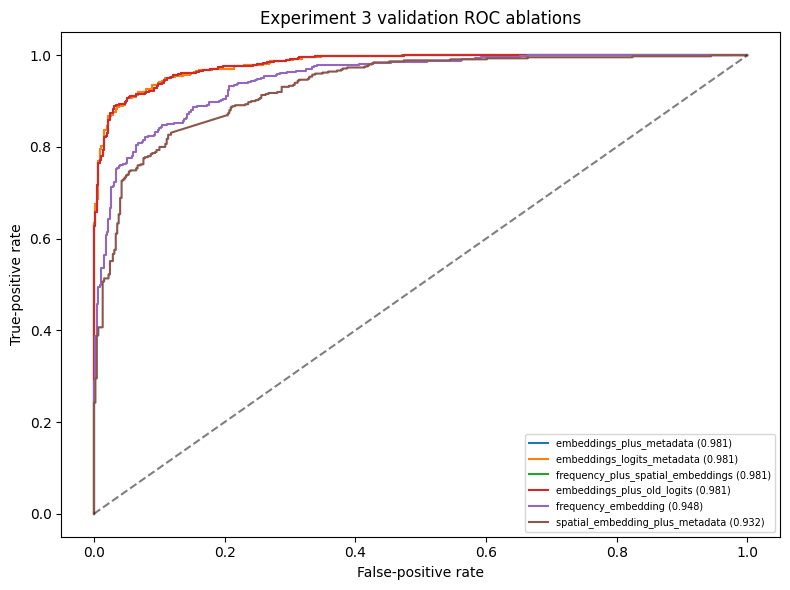

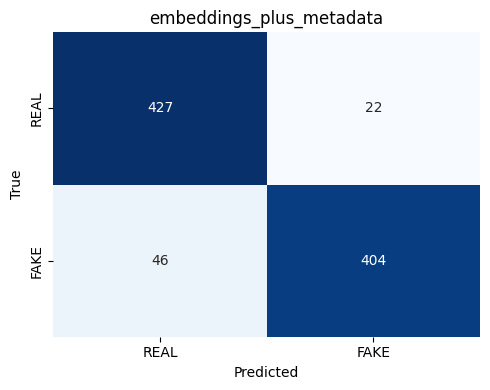

In [17]:
# CELL 14 — PLOTS
fig,ax=plt.subplots(figsize=(8,6))
for name in validation_metrics.head(6)["model"]:
    g=validation_predictions[validation_predictions["model"].eq(name)]
    fpr,tpr,_=roc_curve(g["true_label"],g["fake_probability"]);auc=roc_auc_score(g["true_label"],g["fake_probability"])
    ax.plot(fpr,tpr,label=f"{name} ({auc:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=.5);ax.set_xlabel("False-positive rate");ax.set_ylabel("True-positive rate");ax.set_title("Experiment 3 validation ROC ablations");ax.legend(fontsize=7)
plt.tight_layout();plt.savefig(OUTPUT_DIR/"Experiment3_ROC_Ablations.png",dpi=180,bbox_inches="tight");plt.show()

best_row=validation_metrics.iloc[0];cm=np.array([[best_row["tn"],best_row["fp"]],[best_row["fn"],best_row["tp"]]])
plt.figure(figsize=(5,4));sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,xticklabels=["REAL","FAKE"],yticklabels=["REAL","FAKE"])
plt.title(best_name);plt.xlabel("Predicted");plt.ylabel("True");plt.tight_layout();plt.savefig(OUTPUT_DIR/"Experiment3_Best_Confusion_Matrix.png",dpi=180,bbox_inches="tight");plt.show()

In [18]:
# CELL 15 — DECISION REPORT AND DOWNLOADABLE BUNDLE
best=validation_metrics.iloc[0].to_dict()
best_stability=stability_summary[stability_summary["feature_set"].eq(best_name)].iloc[0].to_dict()
summary={
    "experiment":"DefakeX Experiment 3 — embedding fusion ablation, stability, and cross-generator generalization",
    "train_images":4194,"validation_images":899,"locked_benchmark_images_used":0,
    "stable_diffusion_used":False,"backbones_fine_tuned":False,
    "best_feature_set":best_name,"best_validation_metrics":best,"repeated_group_cv":best_stability,
    "leave_one_generator_out":logo_metrics.to_dict("records"),"shuffled_label_control_auc":float(control_auc),
    "decision_policy":{
        "prefer_simpler_feature_set":"If embeddings-only is statistically tied with logits/metadata, deploy embeddings-only.",
        "accept_complex_fusion_later":"Only if it improves Macro-F1 and worst-generator recall consistently beyond this baseline.",
        "legacy_replay_trigger":"Use legacy/unseen-generator replay if leave-one-generator-out performance drops materially.",
        "do_not_unfreeze_yet":"Frozen embeddings must remain the reference until a fine-tuned model proves a robust improvement."
    }
}
with open(OUTPUT_DIR/"Experiment3_Summary.json","w") as f:json.dump(summary,f,indent=2,default=float)
(OUTPUT_DIR/"README.txt").write_text(
    "Experiment 3 used cached frozen features from Experiment 2. No locked-test image, Stable Diffusion image, or backbone fine-tuning was used. "
    "C and thresholds came from grouped training OOF predictions; validation was used for development comparison.\n")
archive=shutil.make_archive("/kaggle/working/DefakeX_Experiment3_Embedding_Fusion_Hardening","zip",OUTPUT_DIR)
print(json.dumps(summary,indent=2,default=float));print("ZIP:",archive);display(FileLink(archive))

{
  "experiment": "DefakeX Experiment 3 \u2014 embedding fusion ablation, stability, and cross-generator generalization",
  "train_images": 4194,
  "validation_images": 899,
  "locked_benchmark_images_used": 0,
  "stable_diffusion_used": false,
  "backbones_fine_tuned": false,
  "best_feature_set": "embeddings_plus_metadata",
  "best_validation_metrics": {
    "model": "embeddings_plus_metadata",
    "threshold": 0.63,
    "n": 899,
    "accuracy": 0.9243604004449388,
    "balanced_accuracy": 0.924390002474635,
    "macro_f1": 0.924310858863499,
    "roc_auc": 0.9810888393961891,
    "brier_score": 0.05437391559914759,
    "real_recall": 0.9510022271714922,
    "fake_recall": 0.8977777777777778,
    "real_f1": 0.9262472885032538,
    "fake_f1": 0.9223744292237442,
    "tn": 427,
    "fp": 22,
    "fn": 46,
    "tp": 404,
    "C": 0.01,
    "canonical_oof_auc": 0.9643331855942827,
    "canonical_oof_macro_f1": 0.9046251134765579,
    "canonical_oof_balanced_accuracy": 0.9046334953459925

/kaggle/working/DefakeX_Experiment3_Embedding_Fusion_Hardening.zip